Group A (Control): mean |Δμ| = 9.75 ± 0.43 cm
Group B (Minor Novelty): mean |Δμ| = 13.84 ± 0.59 cm
Group C (Major Novelty): mean |Δμ| = 16.99 ± 0.76 cm

Figure saved.


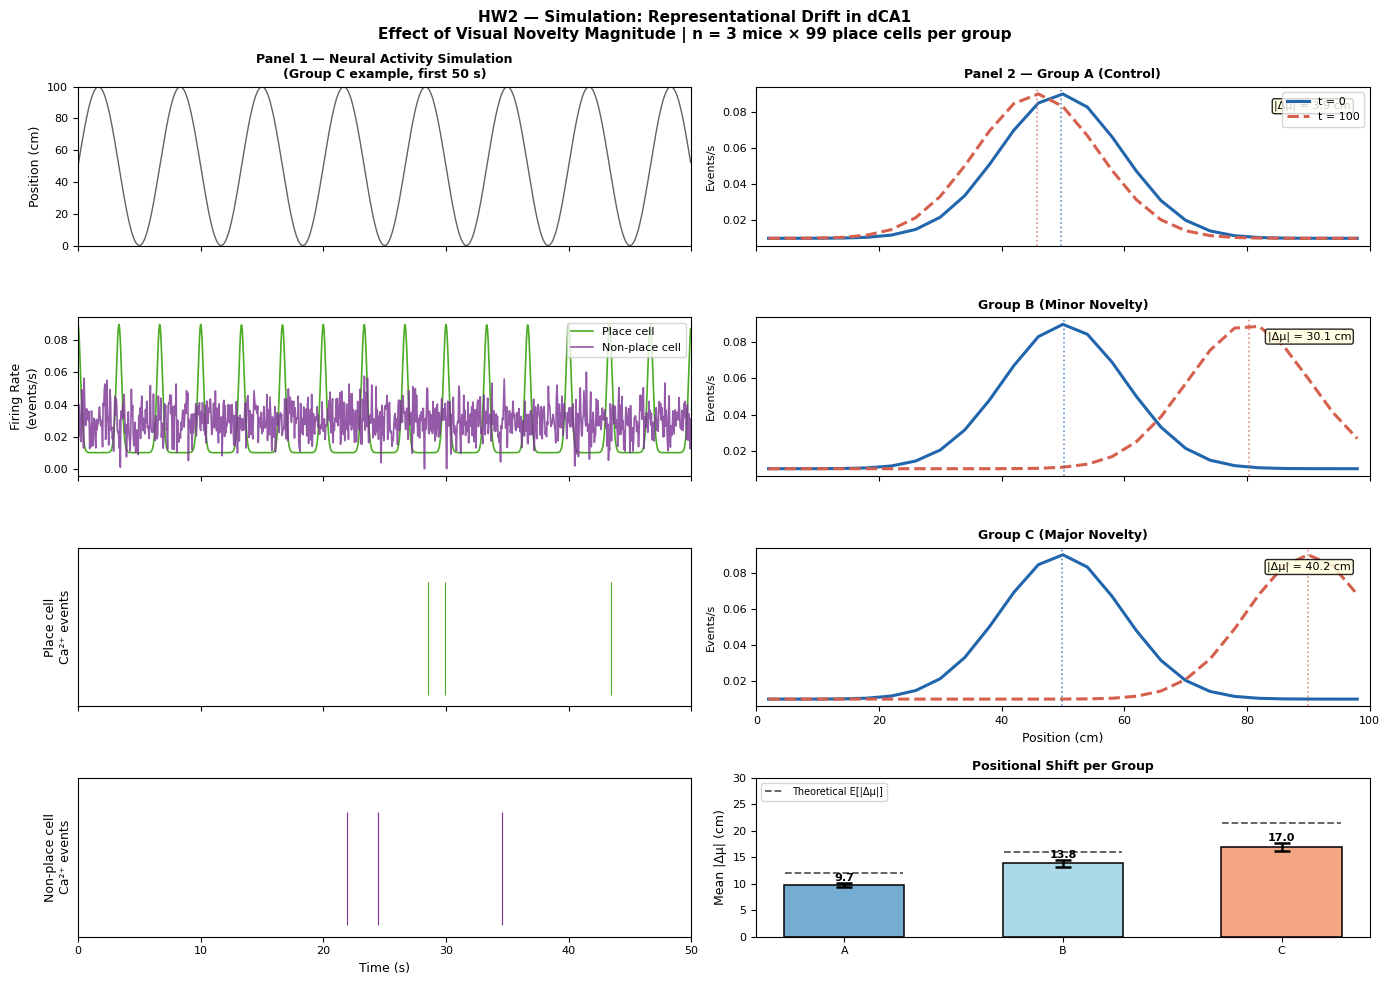

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter1d


# PARAMETERS


np.random.seed(42)

GROUP_NAMES  = ['A (Control)', 'B (Minor Novelty)', 'C (Major Novelty)']
SIGMA_DRIFT  = [15, 20, 27]       # cm: drift std per group (A < B < C)

N_MICE         = 3                # mice per group (between-subjects design)
N_PLACE_CELLS  = 99               # ~22% of 450 active neurons (Khatib et al.)
N_BINS         = 25               # spatial bins (4 cm/bin on 100 cm track)
BIN_CENTERS    = np.linspace(2, 98, N_BINS)

# Firing rate parameters — Ca2+ imaging (events/s, not Hz)
# Sampling rate, neuron count and place cell proportion from Khatib et al. (2023)
# All other parameters are biologically plausible assumed values
LAMBDA_MAX   = 0.08    # peak firing rate, place cells (events/s)
LAMBDA_BASE  = 0.01    # out-of-field baseline, place cells (events/s)
LAMBDA_BG    = 0.03    # background rate, non-place cells (events/s)
SIGMA_EPS    = 0.01    # temporal noise std, non-place cells (events/s)
SIGMA_PLACE  = 10      # spatial tuning width (cm)

MU_MIN, MU_MAX = 10, 90   # place field center range — excludes reward zones
SAMPLING_RATE  = 20        # Hz (from Khatib et al.)
N_FRAMES       = 12000     # 10 min × 60 s × 20 Hz
DISPLAY_FRAMES = 1000      # 50 s shown in spike train panels



# FUNCTIONS


def gaussian_rate_map(x, mu):
    """
    Gaussian tuning curve: expected firing rate as a function of position x.
    λ_i(x) = λ_max * exp(-(x - μ)² / 2σ²) + λ_base
    """
    return LAMBDA_MAX * np.exp(-0.5 * ((x - mu) / SIGMA_PLACE) ** 2) + LAMBDA_BASE


def simulate_position(n_frames):
    """
    Simulate mouse trajectory: sinusoidal back-and-forth on 100 cm track.
    Frequency 0.15 Hz ≈ one lap every 6.7 s, consistent with ~15 cm/s running speed.
    """
    t = np.arange(n_frames) / SAMPLING_RATE
    return 50 * (1 + np.sin(2 * np.pi * 0.15 * t))


def generate_place_spike_train(position, mu):
    """
    Generate Poisson spike train for a place cell given mouse position.
    At each time step dt, P(spike) = firing_rate(x) × dt.
    """
    rates = gaussian_rate_map(position, mu)
    dt    = 1.0 / SAMPLING_RATE
    return (np.random.rand(len(position)) < rates * dt).astype(float)


def generate_non_place_spike_train(n_frames):
    """
    Generate Poisson spike train for a non-place cell.
    Rate = λ_bg + ε(t), ε ~ N(0, σ²_ε), clipped to avoid negative rates.
    """
    noise = np.random.normal(0, SIGMA_EPS, n_frames)
    rates = np.clip(LAMBDA_BG + noise, 0, None)
    dt    = 1.0 / SAMPLING_RATE
    return (np.random.rand(n_frames) < rates * dt).astype(float)


def apply_drift(mu_0, sigma_drift):
    """
    Stochastic drift between sessions: Δμ_i ~ N(0, σ²_drift).
    Place field centers clipped to [MU_MIN, MU_MAX] (track boundaries).
    Returns mu_100 (new centers) and absolute shifts |Δμ|.
    """
    delta  = np.random.normal(0, sigma_drift, len(mu_0))
    mu_100 = np.clip(mu_0 + delta, MU_MIN, MU_MAX)
    return mu_100, np.abs(mu_100 - mu_0)



# SIMULATION LOOP


# Single position trajectory — same behavioral dynamics for all groups
position   = simulate_position(N_FRAMES)
time_axis  = np.arange(DISPLAY_FRAMES) / SAMPLING_RATE   # 0–50 s

mean_shifts, sem_shifts = [], []

# Store one example cell per group for Panel 2 rate maps
ex_rm_t0, ex_rm_t100       = [], []
ex_mu_t0_list, ex_mu_t100_list = [], []

for g, (name, sigma_drift) in enumerate(zip(GROUP_NAMES, SIGMA_DRIFT)):

    all_shifts = []

    for m in range(N_MICE):

        # Randomly initialize place field centers for this mouse
        mu_0 = np.random.uniform(MU_MIN, MU_MAX, N_PLACE_CELLS)

        # Apply representational drift between t=0 and t=100
        mu_100, shifts = apply_drift(mu_0, sigma_drift)
        all_shifts.extend(shifts)

        # Save example cell from the first mouse of each group
        if m == 0:
            # Pick the cell whose field center is closest to the track center (50 cm)
            idx = np.argmin(np.abs(mu_0 - 50))
            ex_rm_t0.append(gaussian_rate_map(BIN_CENTERS, mu_0[idx]))
            ex_rm_t100.append(gaussian_rate_map(BIN_CENTERS, mu_100[idx]))
            ex_mu_t0_list.append(mu_0[idx])
            ex_mu_t100_list.append(mu_100[idx])

    mean_shifts.append(np.mean(all_shifts))
    sem_shifts.append(np.std(all_shifts) / np.sqrt(len(all_shifts)))
    print(f"Group {name}: mean |Δμ| = {mean_shifts[-1]:.2f} ± {sem_shifts[-1]:.2f} cm")

# Spike trains for Panel 1 — use Group C example cell (largest drift)
place_mu_ex = ex_mu_t0_list[2]

spikes_place     = generate_place_spike_train(position[:DISPLAY_FRAMES], place_mu_ex)
spikes_non_place = generate_non_place_spike_train(DISPLAY_FRAMES)

rate_place     = gaussian_rate_map(position[:DISPLAY_FRAMES], place_mu_ex)
rate_non_place = np.clip(LAMBDA_BG + np.random.normal(0, SIGMA_EPS, DISPLAY_FRAMES), 0, None)



# FIGURE 1, 2 PANELS 

fig = plt.figure(figsize=(14, 10))

COL_T0        = '#2166AC'   # blue  — session t=0
COL_T100      = '#D6604D'   # red   — session t=100
COL_PLACE     = '#4DAC26'   # green — place cell
COL_NON_PLACE = '#7B3294'   # purple — non-place cell
BAR_COLORS    = ['#74ADD1', '#ABD9E9', '#F4A582']   # light blue → orange

#  PANEL 1 (left column): Neural activity simulation 

# Row 1 — Simulated mouse position over time
ax_pos = fig.add_subplot(4, 2, 1)
ax_pos.plot(time_axis, position[:DISPLAY_FRAMES], color='#636363', linewidth=1)
ax_pos.set_ylabel('Position (cm)', fontsize=9)
ax_pos.set_title('Panel 1 — Neural Activity Simulation\n(Group C example, first 50 s)',
                 fontsize=9, fontweight='bold')
ax_pos.set_xlim(0, 50)
ax_pos.set_ylim(0, 100)
ax_pos.set_xticklabels([])
ax_pos.tick_params(labelsize=8)

# Row 2 — Instantaneous firing rate over time: place cell vs non-place cell
ax_rate = fig.add_subplot(4, 2, 3)
ax_rate.plot(time_axis, rate_place,     color=COL_PLACE,     linewidth=1.2, label='Place cell')
ax_rate.plot(time_axis, rate_non_place, color=COL_NON_PLACE, linewidth=1.2,
             alpha=0.8, label='Non-place cell')
ax_rate.set_ylabel('Firing Rate\n(events/s)', fontsize=9)
ax_rate.set_xlim(0, 50)
ax_rate.legend(fontsize=8, loc='upper right')
ax_rate.set_xticklabels([])
ax_rate.tick_params(labelsize=8)

# Row 3 — Place cell Ca2+ events (spike train)
ax_sp_place = fig.add_subplot(4, 2, 5)
ax_sp_place.vlines(time_axis[spikes_place > 0], 0, 1,
                   color=COL_PLACE, linewidth=0.8)
ax_sp_place.set_ylabel('Place cell\nCa²⁺ events', fontsize=9)
ax_sp_place.set_xlim(0, 50)
ax_sp_place.set_ylim(-0.1, 1.3)
ax_sp_place.set_yticks([])
ax_sp_place.set_xticklabels([])
ax_sp_place.tick_params(labelsize=8)

# Row 4 — Non-place cell Ca2+ events (spike train)
ax_sp_non = fig.add_subplot(4, 2, 7)
ax_sp_non.vlines(time_axis[spikes_non_place > 0], 0, 1,
                 color=COL_NON_PLACE, linewidth=0.8)
ax_sp_non.set_ylabel('Non-place cell\nCa²⁺ events', fontsize=9)
ax_sp_non.set_xlabel('Time (s)', fontsize=9)
ax_sp_non.set_xlim(0, 50)
ax_sp_non.set_ylim(-0.1, 1.3)
ax_sp_non.set_yticks([])
ax_sp_non.tick_params(labelsize=8)

# PANEL 2 (right column): Rate maps + Summary barplot 

# Rows 1–3: Rate maps t=0 vs t=100, one per group
for g in range(3):
    ax_rm = fig.add_subplot(4, 2, 2 * g + 2)

    ax_rm.plot(BIN_CENTERS, ex_rm_t0[g],
               color=COL_T0,   linewidth=2.2, label='t = 0')
    ax_rm.plot(BIN_CENTERS, ex_rm_t100[g],
               color=COL_T100, linewidth=2.2, linestyle='--', label='t = 100')

    # Vertical dotted lines at place field centers
    ax_rm.axvline(ex_mu_t0_list[g],   color=COL_T0,   linestyle=':', linewidth=1.2, alpha=0.7)
    ax_rm.axvline(ex_mu_t100_list[g], color=COL_T100, linestyle=':', linewidth=1.2, alpha=0.7)

    # Annotate shift magnitude
    shift_val = abs(ex_mu_t100_list[g] - ex_mu_t0_list[g])
    ax_rm.text(0.97, 0.86, f'|Δμ| = {shift_val:.1f} cm',
               transform=ax_rm.transAxes, ha='right', fontsize=8,
               bbox=dict(facecolor='lightyellow', alpha=0.85, boxstyle='round,pad=0.2'))

    title_prefix = 'Panel 2 — ' if g == 0 else ''
    ax_rm.set_title(f'{title_prefix}Group {GROUP_NAMES[g]}', fontsize=9, fontweight='bold')
    ax_rm.set_ylabel('Events/s', fontsize=8)
    ax_rm.set_xlim(0, 100)
    ax_rm.tick_params(labelsize=8)

    if g == 2:
        ax_rm.set_xlabel('Position (cm)', fontsize=9)
    else:
        ax_rm.set_xticklabels([])

    if g == 0:
        ax_rm.legend(fontsize=8, loc='upper right')

# Row 4: Barplot of mean positional shift across groups
ax_bar = fig.add_subplot(4, 2, 8)

bars = ax_bar.bar(range(3), mean_shifts,
                  yerr=sem_shifts, capsize=6,
                  color=BAR_COLORS, edgecolor='black', linewidth=1.1,
                  width=0.55, error_kw={'linewidth': 1.8, 'capthick': 1.8})

# Theoretical expected values: E[|Δμ|] = σ_drift × √(2/π)
expected = [round(s * np.sqrt(2 / np.pi), 1) for s in SIGMA_DRIFT]
for i, exp in enumerate(expected):
    ax_bar.plot([i - 0.27, i + 0.27], [exp, exp], 'k--',
                linewidth=1.3, alpha=0.65,
                label='Theoretical E[|Δμ|]' if i == 0 else '')

# Annotate bar values
for i, (val, sem) in enumerate(zip(mean_shifts, sem_shifts)):
    ax_bar.text(i, val + sem + 0.4, f'{val:.1f}',
                ha='center', fontsize=8, fontweight='bold')

ax_bar.set_xticks(range(3))
ax_bar.set_xticklabels(['A', 'B', 'C'], fontsize=9)
ax_bar.set_ylabel('Mean |Δμ| (cm)', fontsize=9)
ax_bar.set_title('Positional Shift per Group', fontsize=9, fontweight='bold')
ax_bar.set_ylim(0, 30)
ax_bar.legend(fontsize=7, loc='upper left')
ax_bar.tick_params(labelsize=8)

# Global title
fig.suptitle(
    'HW2 — Simulation: Representational Drift in dCA1\n'
    'Effect of Visual Novelty Magnitude | n = 3 mice × 99 place cells per group',
    fontsize=11, fontweight='bold'
)

plt.tight_layout()
plt.savefig('HW2_simulation.png', dpi=150, bbox_inches='tight')
print("\nFigure saved.")
plt.show()
